# Generar trajectòries

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs, on $f(t)=sin(t)$.
$$x'=y + \epsilon f(t)$$ $$y'=x-x^3$$

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from typing import Tuple
import numpy.typing as npt

In [128]:
def edo_duffing_soroll(t, z, random=1, epsilon=0.05, funcio_soroll=np.sin):
    """Paràmetres:
        t: temps
        z: posició al pla R^2
        random: random entre 0 i 2
        epsilon: paràmetre entre 0 i 1 que regula el soroll
        funcio_soroll: pertorbació que depèn del temps
    Retorna el camp vectorial del sistema d'EDOs x'=y+epsilon*f(t); y'=x-x^3.
    """
    x, y = z
    soroll = epsilon *  random * funcio_soroll(t)
    camp_vectorial = [y + soroll, x - x**3]
    return np.array(camp_vectorial)

Paràmetres

In [129]:
epsilon = 0.05
funcio_soroll = np.sin

t_span = (0, 10)
t_steps = 1000
t_valors = np.linspace(t_span[0], t_span[1], t_steps)
condicions_inicials = [[0.3, 0.3]]

radi = 0.3
centre_esquerre = (-1, 0)
centre_dret = (1, 0)
centre_nord = (0, 1)
centre_sud = (0, -1)
resolucio_grafica = 2000

In [130]:

num_trajectories = 3
dimensio = 2

### Gràfiques

#### Funcions auxiliars per graficar

In [131]:
def pertany_a_circumferencia(x: float,
                             y: float, 
                             centre: Tuple[float, float], 
                             radi: float
                             ) -> bool:
    a, b = centre
    return (x-a)**2 + (y-b)**2 <= radi**2

def pertany_a_la_regio_A(x: float, y: float) -> bool:
    return pertany_a_circumferencia(x, y, centre_esquerre, radi) \
        or pertany_a_circumferencia(x, y, centre_dret, radi)

def pertany_a_la_regio_B(x: float, y: float) -> bool:
    return pertany_a_circumferencia(x, y, centre_nord, radi) \
        or pertany_a_circumferencia(x, y, centre_sud, radi)

In [132]:
def grafica_circumferencia(centre: Tuple[float, float],
                           radi: float, 
                           nom_regio:str,
                           resolucio: int = resolucio_grafica):
    theta = np.linspace(0, 2*np.pi, resolucio)
    a, b = centre
    xx = radi*np.cos(theta) + a
    yy = radi*np.sin(theta)
    plt.plot(xx, yy + b, 'black')
    plt.plot(xx, - yy + b, 'black')
    plt.annotate(nom_regio, centre)

def grafica_regio(nom_regio: str, centres: list[Tuple[float, float]]):
    for centre in centres:
        grafica_circumferencia(centre, radi, nom_regio)

def grafica_regio_A():
    nom_regio='A'
    grafica_regio(nom_regio, [centre_esquerre, centre_dret])
    
def grafica_regio_B():
    nom_regio='B'
    grafica_regio(nom_regio, [centre_nord, centre_sud])

In [133]:
def grafica_solucio(edo, t_span, t_valors, condicions_inicials, desa_pdf=False):
    grafica_regio_A()
    grafica_regio_B()
    for ci in condicions_inicials:
        sol = solve_ivp(edo, t_span, ci, t_eval=t_valors)
        plt.plot(sol.y[0], sol.y[1], color = 'orange')
        inici_string = f'Inici = ({ci[0]:.2f}, {ci[1]:.2f})'
        plt.plot(ci[0], ci[1], '-o', label = inici_string)
        final = (sol.y[0][-1], sol.y[1][-1]) #Posició final
        final_string = f'Final = ({final[0]:.2f}, {final[1]:.2f})'
        plt.plot(final[0], final[1], '-o', color = 'red', label = final_string)
    plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid()
    plt.gca().set_aspect('equal')
    if desa_pdf:
        plt.savefig('edo.pdf')
    plt.show()

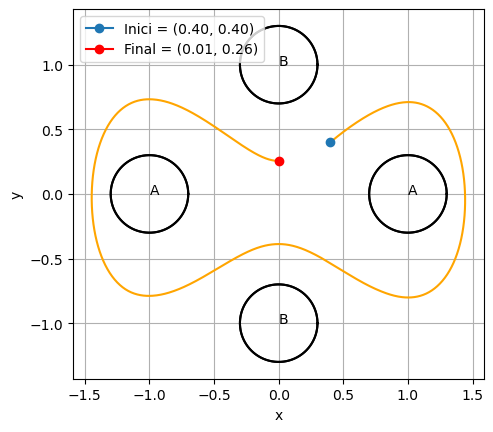

In [134]:
grafica_solucio(edo_duffing_soroll, t_span, t_valors, condicions_inicials=[[0.4, 0.4]])

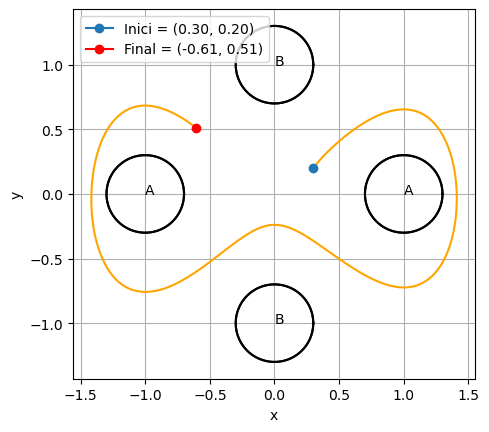

In [135]:
grafica_solucio(edo_duffing_soroll, t_span, t_valors, condicions_inicials=[[0.3, 0.2]])

#### Dibuixa trajectòries

In [136]:
def grafica_trajectories(trajectories, desa_pdf=False):
    grafica_regio_A()
    grafica_regio_B()
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        plt.plot(coordenades_x, coordenades_y) #, color = 'orange')
        
        pos_inicial = (coordenades_x[0], coordenades_y[1])
        inici_string = f'Inici = ({pos_inicial[0]:.2f}, {pos_inicial[1]:.2f})'
        plt.plot(pos_inicial[0], pos_inicial[1], '-o', label = inici_string, color = 'green')
        
        pos_final = (coordenades_x[-1], coordenades_y[-1])
        final_string = f'Final = ({pos_final[0]:.2f}, {pos_final[1]:.2f})'
        plt.plot(pos_final[0], pos_final[1], '-o', label = final_string, color = 'red')
    plt.xlabel('x')
    plt.ylabel('y') 
    # plt.legend(); 
    plt.grid()
    plt.gca().set_aspect('equal')
    if desa_pdf:
        plt.savefig('edo.pdf')
    plt.show()

### 1. Generar $n$ posicions inicials aleatòries

In [137]:
x_min, x_max = (-2, 2)
y_min, y_max = (-1.5, 1.5)

In [138]:
def generar_condicions_inicials(num_ci: int) -> list:
    """num_ci = nombre de condicions inicials"""
    condicions_inicials = []
    for _ in range(num_ci):
        x0 = np.random.uniform(x_min, x_max)
        y0 = np.random.uniform(y_min, y_max)
        while pertany_a_la_regio_A(x0, y0) or pertany_a_la_regio_B(x0, y0):
            x0 = np.random.uniform(x_min, x_max)
            y0 = np.random.uniform(y_min, y_max)
        ci = [x0,y0]
        condicions_inicials.append(ci)
    return condicions_inicials

### 2. Generar $n$ trajectòries, una per a cada posició inicial

Cada trajectòria és la solució de l'EDO avaluada en $k$=`t_steps` instants de temps.

In [139]:
def esdeveniment_A_esq(t, z):
    x, y = z
    a, b = centre_esquerre
    return (x-a)**2 + (y-b)**2 <= radi**2 # menor o igual

def esdeveniment_A_dret(t, z):
    x, y = z
    a, b = centre_dret
    return (x-a)**2 + (y-b)**2 - radi**2

def esdeveniment_B_nord(t, z):
    x, y = z
    a, b = centre_nord
    return (x-a)**2 + (y-b)**2 - radi**2

def esdeveniment_B_sud(t, z):
    x, y = z
    a, b = centre_sud
    return (x-a)**2 + (y-b)**2 - radi**2

esdeveniments_aturada = [esdeveniment_A_esq, esdeveniment_A_dret, 
                         esdeveniment_B_nord, esdeveniment_B_sud]

In [140]:
def generar_trajectories(edo, 
                         condicions_inicials: list,
                         t_span: Tuple[float, float], 
                         t_valors):
    """
    Paràmetres:
        edo: funció que representa el camp vectorial d'una EDO
        num_trajectories: nombre de trajectòries a generar
        condicions_inicials: llista que conté condicions inicials [x0,y0]
        t_valors: np.array[float], conté els instants de temps on avaluem l'EDO
        
    """
    trajectories = np.zeros((num_trajectories, t_steps, dimensio))
    for i, ci in enumerate(condicions_inicials):
        valor_random = 1 # np.random.uniform(0, 2)
        arguments_extra = (valor_random, epsilon, funcio_soroll)
        sol = solve_ivp(edo, t_span, ci,
                        t_eval=t_valors, 
                        args=arguments_extra)
        trajectoria = np.vstack([sol.y[0], sol.y[1]])
        trajectoria = trajectoria.T
        # print(f'{trajectoria = }')
        trajectories[i] = trajectoria
    return trajectories

In [ ]:
condicions_inicials = generar_condicions_inicials(num_trajectories)
trajectories = generar_trajectories(edo_duffing_soroll,
                                    condicions_inicials,
                                    t_span,
                                    t_valors)

In [144]:
print(trajectories.shape)

(3, 1000, 2)


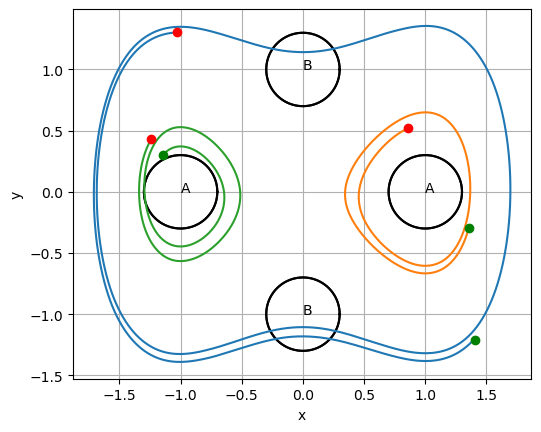

In [143]:
grafica_trajectories(trajectories)

### 3. Calcular distància $r_{ij}$ entre trajectòries

In [107]:
distancies = np.zeros((num_trajectories, num_trajectories))
def calcula_distancia(trajectoria1, trajectoria2) -> float:
    


SyntaxError: incomplete input (4262440460.py, line 3)